In [16]:
import string
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.naive_bayes import MultinomialNB

,Lables,Data
0,neutral,virginamerica what dhepburn said
1,positive,virginamerica plus youve added commercials to ...
2,neutral,virginamerica i didnt today must mean i need t...
3,negative,virginamerica its really aggressive to blast o...
4,negative,virginamerica and its a really big bad thing a...


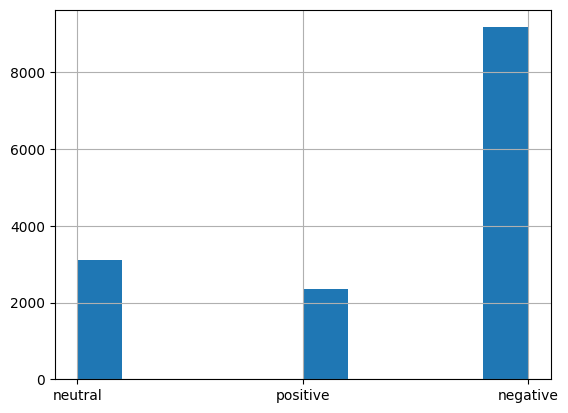

In [11]:
# Text preprocessing
df = pd.read_csv('AirlineTweets.csv', encoding=('ISO-8859-1'))
df = df[['airline_sentiment','text']]
df.columns = ['Lables', 'Data']
df['Data'] = df['Data'].str.lower().str.translate(str.maketrans('', '', string.punctuation))
df['Lables'].hist()
df.head()

In [25]:
# Spliting Data
X_train, X_test, y_train, y_test= train_test_split(df['Data'], df['Lables'], test_size=0.2)

# Vectorizing the texts using TFIDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
trainData = vectorizer.fit_transform(X_train)
testData = vectorizer.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=500)
model.fit(trainData, y_train)
p_test = model.predict(testData)
p_train = model.predict(trainData)
prob_test = model.predict_proba(testData)
prob_train = model.predict_proba(trainData)

In [31]:
# Accuracy of the model
accuracy_test = accuracy_score(y_test, p_test)
print('Accuracy of the logistic regression classifier of test data:', accuracy_test)

accuracy_data = accuracy_score(y_train, p_train)
print('Accuracy of the logistic regression classifier of train data:', accuracy_data)

# F1 score
print('Test F1_score:', f1_score(y_test, p_test, average='weighted'))
print('Train F1_score:', f1_score(y_train, p_train, average='weighted'))

# Confusion matrix
cm_test = confusion_matrix(y_test, p_test)
print('Test confusion matrix:\n', cm_test)
cm_train = confusion_matrix(y_train, p_train)
print('Train confusion matrix:\n', cm_train)

# AUC
test_auc = roc_auc_score(y_test, prob_test, multi_class='ovr')
print('Test AUC score:', test_auc)
train_auc = roc_auc_score(y_train, prob_train, multi_class='ovr')
print('Train AUC score:', train_auc)

Accuracy of the logistic regression classifier of test data: 0.7769808743169399
Accuracy of the logistic regression classifier of train data: 0.8765368852459017
Test F1_score: 0.7621669405233893
Train F1_score: 0.8711277847671861
Test confusion matrix:
 [[1689   83   25]
 [ 302  308   47]
 [ 143   53  278]]
Train confusion matrix:
 [[7213  115   53]
 [ 723 1627   92]
 [ 355  108 1426]]
Test AUC score: 0.8939216086996109
Train AUC score: 0.9663080619735359


In [55]:
# Binary classification
mask = df['Lables'] != 'neutral'
df = df[mask]

# Spliting Data
X_train, X_test, y_train, y_test= train_test_split(df['Data'], df['Lables'], test_size=0.2)

# Vectorizing the texts using TFIDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english')
trainData = vectorizer.fit_transform(X_train)
testData = vectorizer.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=500)
model.fit(trainData, y_train)
p_test = model.predict(testData)
p_train = model.predict(trainData)
prob_test = model.predict_proba(testData)
prob_train = model.predict_proba(trainData)

# Accuracy of the model
accuracy_test = accuracy_score(y_test, p_test)
print('Accuracy of the logistic regression classifier of test data:', accuracy_test)

accuracy_data = accuracy_score(y_train, p_train)
print('Accuracy of the logistic regression classifier of train data:', accuracy_data)

# F1 score
print('Test F1_score:', f1_score(y_test, p_test, pos_label='positive'))
print('Train F1_score:', f1_score(y_train, p_train, pos_label='positive'))

# Confusion matrix
cm_test = confusion_matrix(y_test, p_test)
print('Test confusion matrix:\n', cm_test)
cm_train = confusion_matrix(y_train, p_train)
print('Train confusion matrix:\n', cm_train)

# AUC
test_auc = roc_auc_score(y_test, prob_test[:, 1])
print('Test AUC score:', test_auc)
train_auc = roc_auc_score(y_train, prob_train[:,1])
print('Train AUC score:', train_auc)


Accuracy of the logistic regression classifier of test data: 0.8977912516240797
Accuracy of the logistic regression classifier of train data: 0.9184358752166378
Test F1_score: 0.7183770883054893
Train F1_score: 0.7548029957668512
Test confusion matrix:
 [[1772   28]
 [ 208  301]]
Train confusion matrix:
 [[7320   58]
 [ 695 1159]]
Test AUC score: 0.9493909626719056
Train AUC score: 0.9812765903939612
